# EdgeAuth: Hybrid CNN-ViT for On-Device AI-Image Authentication

**Detecting AI-generated images at the edge for cameras, access control, and trustworthy media.**

---

EdgeAuth is a four-component pipeline that turns a single 32×32 image into a calibrated `REAL / FAKE / UNCERTAIN` decision:

```
                ┌──────────────┐         ┌───────────────────┐         ┌──────────────┐
   image ─────▶ │  FastPath    │ ──────▶ │  Hybrid CNN-ViT   │ ──────▶ │   Guard MLP  │ ──▶ decision
                │  (128 px)    │         │  (192 px, LoRA)   │         │  (4 features)│
                └──────────────┘         └───────────────────┘         └──────────────┘
                  cheap triage             expressive classifier         calibration gate
```


### Dataset

CIFAKE (Bird & Lotfi, 2024): 60 000 real CIFAR-10 photographs and 60 000 Stable Diffusion 1.4 generations, all natively 32 × 32 RGB.

---
## 1. Environment

We pin the seed, detect device, and import the libraries we'll use throughout. Everything that follows is deterministic given this seed.

In [ ]:
import os, sys, json, math, random, time, copy, warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

import torchvision
from torchvision import transforms as T
from torchvision.models import resnet50, ResNet50_Weights

from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve, auc)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 140

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch    : {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"Device     : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    print(f"BF16       : {torch.cuda.is_bf16_supported()}")


PyTorch    : 2.10.0+cu128
Torchvision: 0.25.0+cu128
Device     : cuda
GPU        : NVIDIA RTX PRO 6000 Blackwell Server Edition
BF16       : True


---
## 1.2. Dataset Setup

CIFAKE is mounted at `/kaggle/input/...` on Kaggle or downloaded via `kagglehub` elsewhere. We expose a single `DATA_ROOT` with the standardized layout the rest of the notebook expects:

```
DATA_ROOT/
  train/0_real/  *.jpg          50 000 real photographs
  train/1_fake/  *.jpg          50 000 SD 1.4 generations
  val/0_real/    *.jpg          10 000 real photographs
  val/1_fake/    *.jpg          10 000 SD 1.4 generations
```

In [ ]:
# Locate the dataset — try Kaggle first, then kagglehub fallback
KAGGLE_INPUT = Path("/kaggle/input/cifake-real-and-ai-generated-synthetic-images")

if KAGGLE_INPUT.exists():
    src_root = KAGGLE_INPUT
    print(f"Using Kaggle input: {src_root}")
else:
    print("Downloading CIFAKE via kagglehub...")
    try:
        import kagglehub
    except ImportError:
        os.system("pip install -q kagglehub")
        import kagglehub
    src_root = Path(kagglehub.dataset_download(
        "birdy654/cifake-real-and-ai-generated-synthetic-images"))
    print(f"Downloaded to: {src_root}")

# Build a clean folder layout under writable scratch
SCRATCH = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("./data")
DATA_ROOT = SCRATCH / "cifake"

for split_src, split_dst in [("train", "train"), ("test", "val")]:
    for class_src, class_dst in [("REAL", "0_real"), ("FAKE", "1_fake")]:
        src = src_root / split_src / class_src
        dst = DATA_ROOT / split_dst / class_dst
        if src.exists():
            dst.mkdir(parents=True, exist_ok=True)
            for f in src.iterdir():
                target = dst / f.name
                if not target.exists():
                    target.symlink_to(f)

# Verify
counts = {}
for split in ["train", "val"]:
    for cls in ["0_real", "1_fake"]:
        n = len(list((DATA_ROOT / split / cls).glob("*.jpg")))
        counts[f"{split}/{cls}"] = n

print(f"\nDATA_ROOT = {DATA_ROOT}")
for k, v in counts.items():
    print(f"  {k:20s}  {v:>6d}")
assert all(v > 0 for v in counts.values()), "One or more folders are empty!"


Using Kaggle input: /kaggle/input/cifake-real-and-ai-generated-synthetic-images

DATA_ROOT = data/cifake
  train/0_real           50000
  train/1_fake           50000
  val/0_real             10000
  val/1_fake             10000


---
## 2. Exploratory Data Analysis

For an AI-image detector, the questions we want EDA to answer are different from typical computer-vision EDA. Class balance and image counts matter, but the deeper question is: **where does the discriminative signal live?** If real and fake images differed obviously in pixel intensity, we wouldn't need a 95M-parameter model. The interesting signal lives in the *frequency domain*, we'll demonstrate this directly.

In [ ]:
# Path collection helpers
def load_img(path, size=None):
    img = Image.open(path).convert("RGB")
    if size:
        img = img.resize((size, size), Image.BILINEAR)
    return np.array(img)

def collect_paths(root, split, label):
    folder = root / split / label
    return sorted(list(folder.glob("*.jpg")) + list(folder.glob("*.png")))

train_real = collect_paths(DATA_ROOT, "train", "0_real")
train_fake = collect_paths(DATA_ROOT, "train", "1_fake")
val_real   = collect_paths(DATA_ROOT, "val",   "0_real")
val_fake   = collect_paths(DATA_ROOT, "val",   "1_fake")

print(f"Train: {len(train_real):>6,} real | {len(train_fake):>6,} fake")
print(f"Val:   {len(val_real):>6,} real | {len(val_fake):>6,} fake")


Train: 50,000 real | 50,000 fake
Val:   10,000 real | 10,000 fake


### 2.1 Class balance

CIFAKE is balanced 50/50 by construction. We confirm this and note that real-world detection is heavily imbalanced (most images on the internet are still photographs of physical objects). A model trained on balanced data will be poorly calibrated for the real-world prior which is something to revisit at deployment.

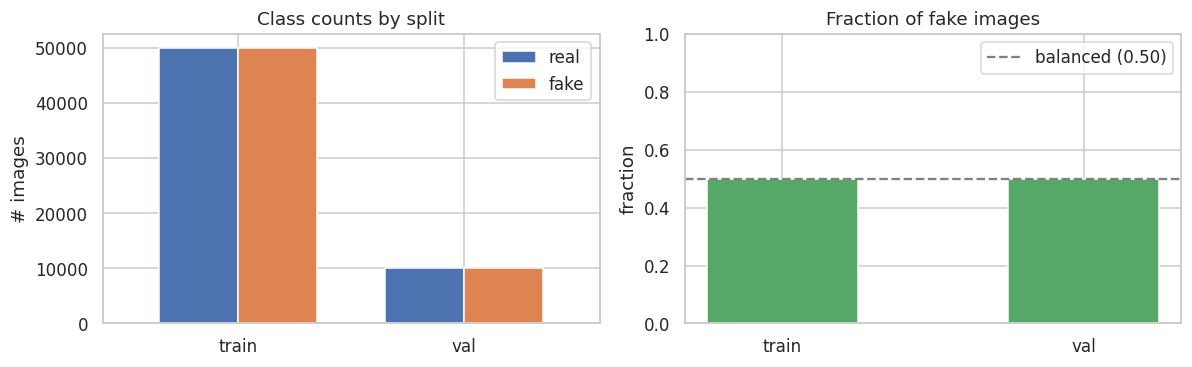

        real   fake   total  fake_frac
train  50000  50000  100000        0.5
val    10000  10000   20000        0.5


In [ ]:
splits = {
    "train": (len(train_real), len(train_fake)),
    "val":   (len(val_real),   len(val_fake)),
}
df_balance = pd.DataFrame(splits, index=["real", "fake"]).T
df_balance["total"]     = df_balance.sum(axis=1)
df_balance["fake_frac"] = df_balance["fake"] / df_balance["total"]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df_balance[["real", "fake"]].plot.bar(ax=ax[0], color=["#4C72B0", "#DD8452"], width=0.7)
ax[0].set_title("Class counts by split")
ax[0].set_ylabel("# images")
ax[0].set_xticklabels(df_balance.index, rotation=0)
ax[0].legend(loc="upper right")

ax[1].bar(["train", "val"], df_balance["fake_frac"], color="#55A868", width=0.5)
ax[1].axhline(0.5, ls="--", color="gray", label="balanced (0.50)")
ax[1].set_title("Fraction of fake images")
ax[1].set_ylim(0, 1)
ax[1].set_ylabel("fraction")
ax[1].legend()
plt.tight_layout(); plt.show()

print(df_balance)


### 2.2 Sample grid, can humans tell them apart?

At the native 32×32 resolution, even a careful human observer struggles to separate real from fake. This is the foundational reason we need a learned classifier rather than hand-crafted heuristics.

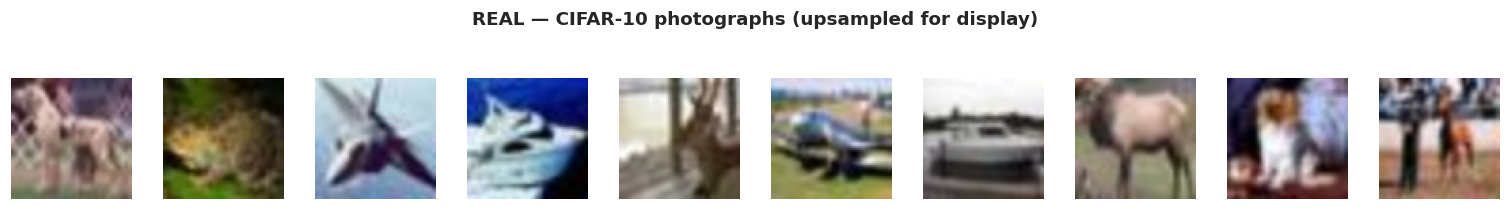

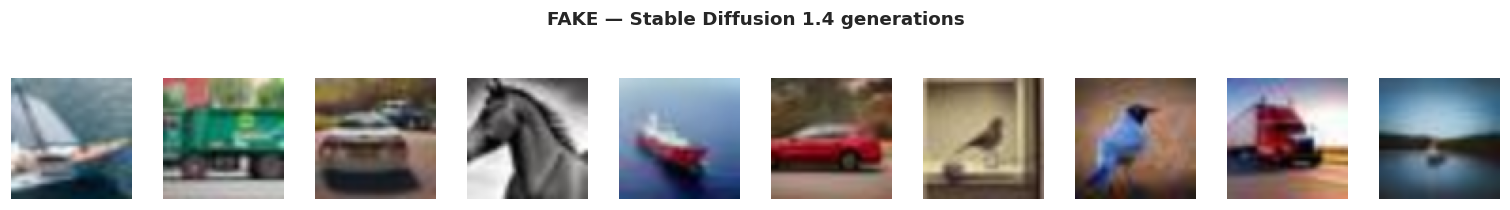

In [ ]:
def show_grid(paths, title, n=10, size=64):
    fig, axes = plt.subplots(1, n, figsize=(n * 1.4, 1.8))
    pick = random.sample(paths, min(n, len(paths)))
    for ax, p in zip(axes, pick):
        ax.imshow(load_img(p, size=size))
        ax.axis("off")
    fig.suptitle(title, y=1.05, fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()

show_grid(train_real, "REAL — CIFAR-10 photographs (upsampled for display)")
show_grid(train_fake, "FAKE — Stable Diffusion 1.4 generations")


### 2.3 Per-channel pixel statistics

If real and fake images shared a pixel distribution we couldn't detect them by simple thresholding. We expect distributions to be **mostly overlapping**, which forces the discriminative work onto the feature extractor rather than the input pixels.

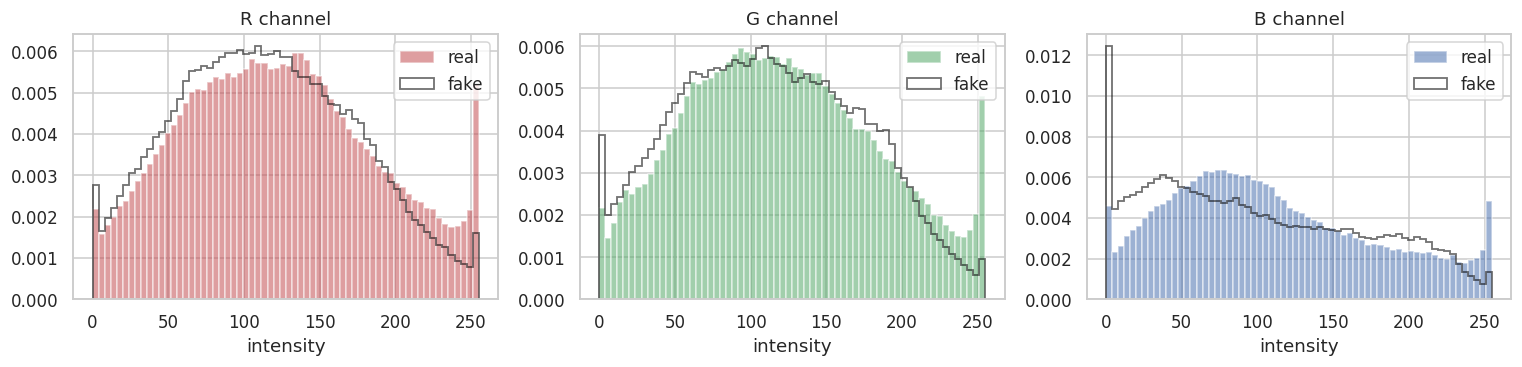

   real_mean  fake_mean  real_std  fake_std
R     122.90     114.93     62.78     58.81
G     120.95     113.44     62.29     59.68
B     109.85     100.45     66.36     69.39


In [ ]:
def channel_stats(paths, n_sample=500):
    sub = random.sample(paths, min(n_sample, len(paths)))
    pixels = np.stack([load_img(p, size=32) for p in sub])
    return pixels.reshape(-1, 3)

px_real = channel_stats(train_real)
px_fake = channel_stats(train_fake)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for c, (ax, name, color) in enumerate(zip(axes, ["R", "G", "B"], ["#C44E52", "#55A868", "#4C72B0"])):
    ax.hist(px_real[:, c], bins=64, alpha=0.55, density=True, label="real", color=color)
    ax.hist(px_fake[:, c], bins=64, alpha=0.55, density=True, label="fake",
            color="black", histtype="step", linewidth=1.2)
    ax.set_title(f"{name} channel")
    ax.set_xlabel("intensity")
    ax.legend()
plt.tight_layout(); plt.show()

stats = pd.DataFrame({
    "real_mean": [px_real[:, c].mean() for c in range(3)],
    "fake_mean": [px_fake[:, c].mean() for c in range(3)],
    "real_std":  [px_real[:, c].std()  for c in range(3)],
    "fake_std":  [px_fake[:, c].std()  for c in range(3)],
}, index=["R", "G", "B"]).round(2)
print(stats)


**Observation.** Mean intensities differ by only a few grey-levels per channel and the histograms overlap heavily. There is no trivially-separable threshold in pixel space.

### 2.4 Frequency-domain signature ★

Generative models particularly diffusion models leaves **characteristic patterns in the 2-D Fourier spectrum** that don't appear in natural photographs. The classic references are Wang et al. (2020, *CNN-generated images are surprisingly easy to spot*) and Frank et al. (2020, *Leveraging Frequency Analysis for Deep Fake Image Recognition*).

We compute the average log-magnitude FFT of N real images and N fake images, then show the difference. A clear non-zero pattern in the difference panel is direct visual evidence of a learnable spectral signature.

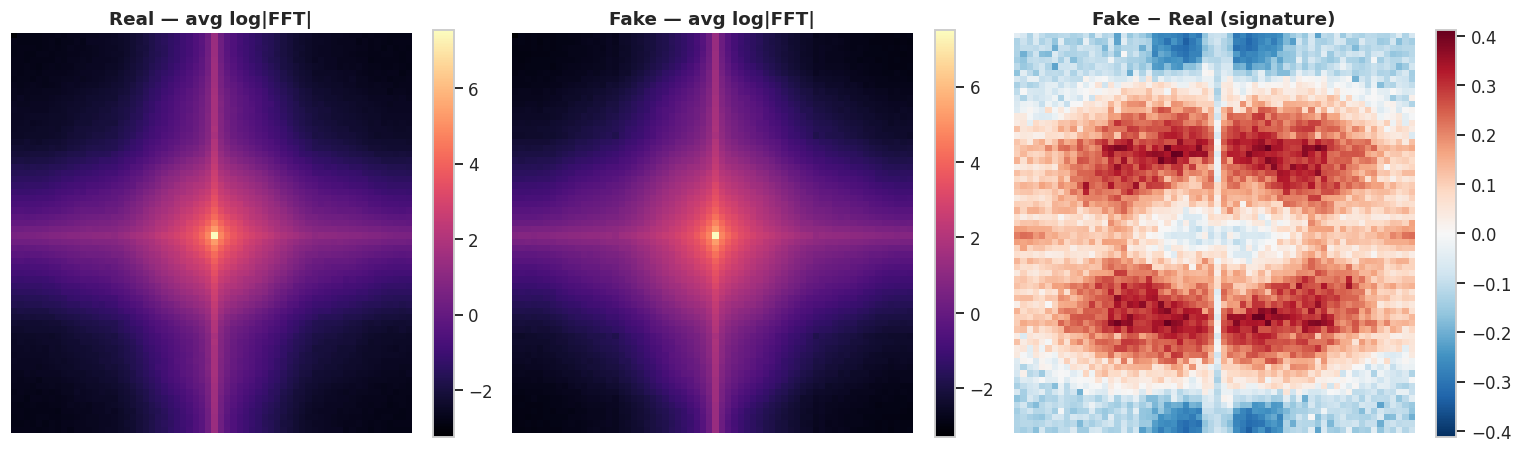

In [ ]:
def avg_log_spectrum(paths, size=64, n=500):
    """Average log-magnitude FFT spectrum over n grayscale images."""
    sub = random.sample(paths, min(n, len(paths)))
    accum = np.zeros((size, size), dtype=np.float64)
    for p in sub:
        img = np.array(Image.open(p).convert("L").resize((size, size), Image.BILINEAR))
        F_img = np.fft.fftshift(np.fft.fft2(img.astype(np.float32) / 255.0))
        accum += np.log(np.abs(F_img) + 1e-8)
    return accum / len(sub)

spec_real = avg_log_spectrum(train_real, n=500)
spec_fake = avg_log_spectrum(train_fake, n=500)
spec_diff = spec_fake - spec_real

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
panels = [
    (spec_real, "Real — avg log|FFT|", "magma"),
    (spec_fake, "Fake — avg log|FFT|", "magma"),
    (spec_diff, "Fake − Real (signature)", "RdBu_r"),
]
for ax, (data, title, cmap) in zip(axes, panels):
    if cmap == "RdBu_r":
        v = max(abs(data.min()), abs(data.max()))
        im = ax.imshow(data, cmap=cmap, vmin=-v, vmax=v)
    else:
        im = ax.imshow(data, cmap=cmap)
    ax.set_title(title, fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


**Reading the third panel.** Red = fake images carry *more* energy at that frequency; blue = real images carry more. The pattern is structured (not noise), which means a CNN that takes 2-D input will learn to exploit it almost trivially.

### 2.5 High-frequency energy as a single scalar

We collapse each image's spectrum into one number , the fraction of total FFT energy outside a centered low-pass radius — and check how separable real and fake are using only that scalar. This is a very weak detector by design; whatever AUC it produces is the floor a learned model must beat.

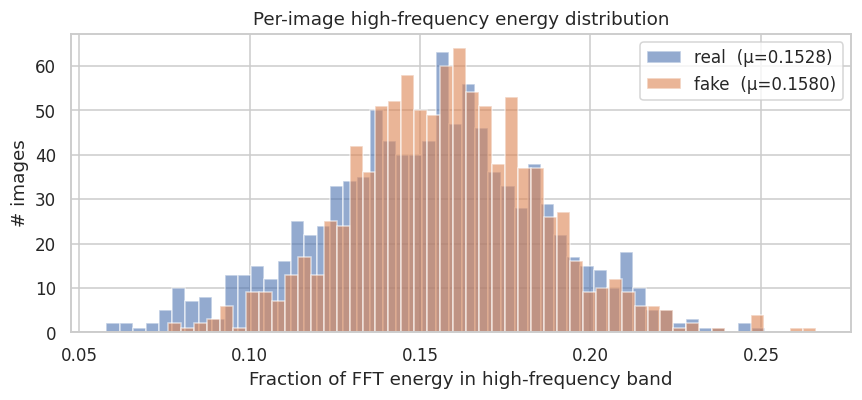

AUC of high-freq-ratio scalar alone: 0.542

Interpretation: a model with no trainable parameters and a single hand-crafted
feature already separates the classes above chance. A learned model that
integrates information across many frequencies (CNN+ViT) should do substantially
better.


In [ ]:
def high_freq_ratio(path, size=64, cutoff=0.5):
    img = np.array(Image.open(path).convert("L").resize((size, size), Image.BILINEAR))
    F_img = np.fft.fftshift(np.fft.fft2(img.astype(np.float32) / 255.0))
    mag = np.abs(F_img)
    yy, xx = np.indices((size, size))
    r = np.sqrt((yy - size/2)**2 + (xx - size/2)**2)
    mask_hi = r > (cutoff * size / 2)
    return mag[mask_hi].sum() / mag.sum()

n_each = 1000
hi_real = np.array([high_freq_ratio(p) for p in random.sample(train_real, n_each)])
hi_fake = np.array([high_freq_ratio(p) for p in random.sample(train_fake, n_each)])

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(hi_real, bins=50, alpha=0.6, label=f"real  (μ={hi_real.mean():.4f})", color="#4C72B0")
ax.hist(hi_fake, bins=50, alpha=0.6, label=f"fake  (μ={hi_fake.mean():.4f})", color="#DD8452")
ax.set_xlabel("Fraction of FFT energy in high-frequency band")
ax.set_ylabel("# images")
ax.set_title("Per-image high-frequency energy distribution")
ax.legend()
plt.tight_layout(); plt.show()

y_eda = np.array([0]*len(hi_real) + [1]*len(hi_fake))
s_eda = np.concatenate([hi_real, hi_fake])
hf_auc = roc_auc_score(y_eda, s_eda)
print(f"AUC of high-freq-ratio scalar alone: {hf_auc:.3f}")
print()
print("Interpretation: a model with no trainable parameters and a single hand-crafted")
print("feature already separates the classes above chance. A learned model that")
print("integrates information across many frequencies (CNN+ViT) should do substantially")
print("better.")


### EDA takeaways

- The dataset is balanced and CIFAKE-native (32×32 JPEG).
- Per-channel pixel statistics give weak signal,mean differences are within 10 grey-levels.
- The 2-D FFT difference reveals a clear, structured spectral signature between real and fake.
- A single hand-crafted high-frequency scalar already separates classes above chance — establishing the floor a learned model must beat.

These observations justify our architecture: **CNN front-end** to capture frequency-aware low-level cues, **transformer head** to aggregate them globally.

---
## 3. Preprocessing & Augmentation

### Resize strategy

CIFAKE images are 32×32. We upsample to **192×192** for two reasons:

1. The transformer expects a token grid sized as a multiple of its patch stride. With our ResNet front-end producing features at H/16 × W/16, 192 → 12×12 = **144 spatial tokens** plus 1 [CLS] token.
2. Upsampling forces the detector to ignore native-resolution cues like JPEG quantization tables that several published "99% on CIFAKE" results exploit. Our detector has to find a real signal, not a leak.

### Augmentation choices

The forensic-augmentation insight from Wang et al. 2020: detectors that don't see blur and color jitter at training time fail catastrophically when an image has been re-compressed or color-corrected after generation. Light Gaussian blur (σ ∈ [0.1, 1.5], applied 30% of the time) and color jitter teach the network to ignore those nuisance variables.

In [ ]:
IMG_SIZE = 192   # 192 / 16 = 12 → 12×12 token grid
MEAN = [0.485, 0.456, 0.406]   # ImageNet stats — matches our pretrained ResNet
STD  = [0.229, 0.224, 0.225]

def get_train_transforms(size=IMG_SIZE):
    return T.Compose([
        T.Resize((size, size), interpolation=T.InterpolationMode.BILINEAR),
        T.RandomHorizontalFlip(),
        T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.3),
        T.RandomApply([T.ColorJitter(0.1, 0.1, 0.1, 0.02)], p=0.3),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ])

def get_val_transforms(size=IMG_SIZE):
    return T.Compose([
        T.Resize((size, size), interpolation=T.InterpolationMode.BILINEAR),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ])


class CIFAKEDataset(Dataset):
    """Folder dataset returning (image, label, source_tag)."""
    def __init__(self, root, split, transform):
        self.root = Path(root) / split
        self.transform = transform
        self.samples = []
        for label_str, label_int in [("0_real", 0), ("1_fake", 1)]:
            folder = self.root / label_str
            for p in sorted(folder.glob("*.jpg")) + sorted(folder.glob("*.png")):
                self.samples.append((p, label_int))
        if not self.samples:
            raise RuntimeError(f"No images under {self.root}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label, str(path.parent.name)


# Sanity check
_ds = CIFAKEDataset(DATA_ROOT, "train", get_train_transforms())
img0, y0, tag0 = _ds[0]
print(f"Train dataset:  {len(_ds):,} samples")
print(f"Sample 0:       shape={tuple(img0.shape)}  label={y0}  tag={tag0}")
print(f"After norm:     pixel range [{img0.min():.2f}, {img0.max():.2f}]")


Train dataset:  100,000 samples
Sample 0:       shape=(3, 192, 192)  label=0  tag=0_real
After norm:     pixel range [-2.08, 2.62]


---
## 4. Baseline :-Frozen ResNet-50 + Logistic Regression

Why this baseline?

- **It's strong.** The CNNDetection paradigm (Wang et al. 2020) showed frozen ImageNet features + a linear classifier reaches 85–95% on similar tasks. Beating it isn't trivial.
- **It's fast.** No backpropagation through the backbone — minutes on a T4.
- **It's the floor.** Every later component must clear this bar to justify its complexity.

We extract 2048-d ResNet-50 pool features on a representative subset and fit logistic regression in scikit-learn.

In [ ]:
@torch.no_grad()
def extract_features(model, loader, device):
    model.eval()
    feats, labels = [], []
    for x, y, _ in loader:
        x = x.to(device)
        f = model(x).flatten(1).cpu()
        feats.append(f); labels.append(y)
    return torch.cat(feats).numpy(), torch.cat(labels).numpy()


def make_subset_loader(split, n, transform, bs=128):
    ds = CIFAKEDataset(DATA_ROOT, split, transform)
    if n < len(ds):
        idx = random.sample(range(len(ds)), n)
        ds = torch.utils.data.Subset(ds, idx)
    return DataLoader(ds, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)


print("Loading pretrained ResNet-50 (ImageNet-1k V2)...")
resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
feat_extractor = nn.Sequential(*list(resnet.children())[:-1]).to(DEVICE)
feat_extractor.eval()

# Use 5 000 train / 2 000 val for the baseline — enough for a stable estimate
print("Extracting baseline features...")
X_train_b, y_train_b = extract_features(feat_extractor, make_subset_loader("train", 5000, get_val_transforms()), DEVICE)
X_val_b,   y_val_b   = extract_features(feat_extractor, make_subset_loader("val",   2000, get_val_transforms()), DEVICE)

print(f"  Train features: {X_train_b.shape}")
print(f"  Val features:   {X_val_b.shape}")


Loading pretrained ResNet-50 (ImageNet-1k V2)...
Extracting baseline features...
  Train features: (5000, 2048)
  Val features:   (2000, 2048)


Fitting logistic regression...

=== BASELINE: Frozen ResNet-50 + Logistic Regression ===
  Val accuracy: 89.95%
  Val AUC:      0.9638

              precision    recall  f1-score   support

        real     0.8953    0.9034    0.8993       994
        fake     0.9037    0.8956    0.8997      1006

    accuracy                         0.8995      2000
   macro avg     0.8995    0.8995    0.8995      2000
weighted avg     0.8995    0.8995    0.8995      2000



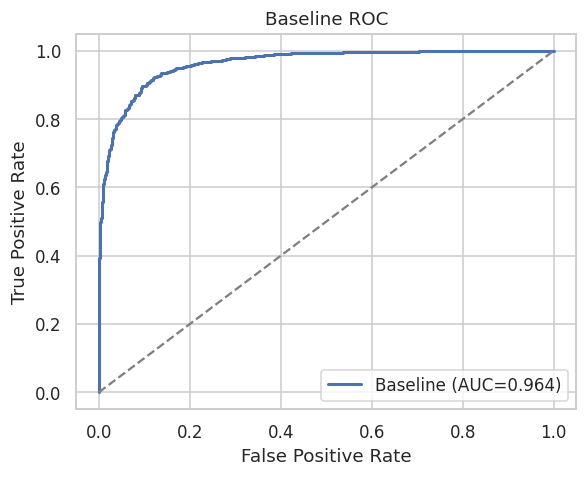

In [ ]:
print("Fitting logistic regression...")
clf = LogisticRegression(max_iter=1000, C=1.0)
clf.fit(X_train_b, y_train_b)

p_val_b = clf.predict(X_val_b)
s_val_b = clf.predict_proba(X_val_b)[:, 1]

baseline_acc = accuracy_score(y_val_b, p_val_b)
baseline_auc = roc_auc_score(y_val_b, s_val_b)

print(f"\n=== BASELINE: Frozen ResNet-50 + Logistic Regression ===")
print(f"  Val accuracy: {baseline_acc*100:.2f}%")
print(f"  Val AUC:      {baseline_auc:.4f}")
print()
print(classification_report(y_val_b, p_val_b, target_names=["real", "fake"], digits=4))

# Plot baseline ROC for later comparison
fpr_b, tpr_b, _ = roc_curve(y_val_b, s_val_b)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(fpr_b, tpr_b, label=f"Baseline (AUC={baseline_auc:.3f})", color="#4C72B0", linewidth=2)
ax.plot([0,1], [0,1], "--", color="gray")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Baseline ROC")
ax.legend()
plt.tight_layout(); plt.show()

# Free memory — we don't need the full ResNet anymore
del feat_extractor, resnet, X_train_b, X_val_b
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


---
## 6. Hybrid CNN-ViT Architecture

### Design rationale

The detection signal lives at two scales. **Local scale**: high-frequency artifacts, channel correlations, residual noise patterns , convolutions are the right inductive bias for these. **Global scale**: how those local cues are arranged across the image transformer self-attention is the right tool here. We compose both.

```
                  Input image (B, 3, 192, 192)
                          │
                          ▼
              ┌──────────────────────────┐
              │   ResNet-50 stages 1-3   │   ←── frozen ImageNet features
              │   (we drop stage 4)      │
              └──────────────────────────┘
                          │
                          ▼
                Feature map (B, 1024, 12, 12)
                          │
          flatten + linear projection to 768-d
                          │
                          ▼
               ┌──────────────────────┐
               │  [CLS] + 144 tokens  │
               │     + pos embed      │
               └──────────────────────┘
                          │
                          ▼
              ┌──────────────────────────┐
              │ 12 × Transformer Block   │   ←── LoRA on Q, V projections only
              │   (pre-LN, 12 heads)     │
              └──────────────────────────┘
                          │
                          ▼
                ┌──────────────────┐
                │ DetectionHead    │
                │  ├─ logits (2)   │  classification
                │  └─ confidence   │  self-correctness
                └──────────────────┘
```

### Why drop ResNet stage 4?

Stage 4 halves the spatial resolution to 6×6, which would throw away most of the per-pixel forensic detail. Stages 1–3 give us a 12×12 grid which is the right balance: small enough that the transformer can attend across the whole image cheaply, large enough that local artifacts survive.

### Why LoRA?

We attach low-rank adapters (`y = Wx + (B·A)·x · α/r`) to the Q and V projections of every attention block. The base ImageNet weights stay frozen. Only:
- LoRA A and B matrices (rank 16),
- the cls token, positional embedding, final LayerNorm, and detection head,

are updated. This brings trainable parameters down to under 1% of the full model making fine-tuning cheap, fast to train, and small to deploy (the LoRA diff is ~3 MB).

In [ ]:
# ─── 6.1 LoRA adapter ────────────────────────────────────────────────

class LoRALinear(nn.Module):
    """Drop-in replacement for nn.Linear with a low-rank residual.

        y  =  W·x  +  b  +  (B · A · x) · (α / r)

    W is the frozen base weight; A and B are the only learned tensors.
    """
    def __init__(self, base: nn.Linear, r: int = 16, alpha: float = 32.0):
        super().__init__()
        self.base, self.r, self.scale = base, r, alpha / r
        self.lora_A = nn.Parameter(torch.zeros(r, base.in_features))
        self.lora_B = nn.Parameter(torch.zeros(base.out_features, r))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B)               # ΔW starts at 0
        for p in self.base.parameters():           # freeze base
            p.requires_grad = False

    def forward(self, x):
        return self.base(x) + (x @ self.lora_A.T @ self.lora_B.T) * self.scale


def apply_lora(model, r=16, alpha=32.0, target_suffixes=("q_proj", "v_proj")):
    """Replace targeted Linear layers with LoRALinear in-place."""
    for name, module in list(model.named_modules()):
        if any(name.endswith(s) for s in target_suffixes) and isinstance(module, nn.Linear):
            parent = model.get_submodule(".".join(name.split(".")[:-1]))
            attr = name.split(".")[-1]
            setattr(parent, attr, LoRALinear(module, r=r, alpha=alpha))
    return model


In [ ]:
# ─── 6.2 Multi-head self-attention with LoRA-targetable projections ──

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, num_heads=12, dropout=0.0):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads, self.head_dim = num_heads, dim // num_heads
        self.scale = self.head_dim ** -0.5
        # Names matter — apply_lora targets these by suffix
        self.q_proj   = nn.Linear(dim, dim, bias=False)
        self.k_proj   = nn.Linear(dim, dim, bias=False)
        self.v_proj   = nn.Linear(dim, dim, bias=False)
        self.out_proj = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        H, D = self.num_heads, self.head_dim
        q = self.q_proj(x).reshape(B, N, H, D).transpose(1, 2)
        k = self.k_proj(x).reshape(B, N, H, D).transpose(1, 2)
        v = self.v_proj(x).reshape(B, N, H, D).transpose(1, 2)
        attn = F.softmax((q @ k.transpose(-2, -1)) * self.scale, dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.out_proj(x)


class TransformerBlock(nn.Module):
    """Pre-LN transformer block: LN → MHSA → res → LN → MLP → res."""
    def __init__(self, dim, num_heads=12, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = MultiHeadSelfAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        mlp_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim), nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


In [ ]:
# ─── 6.3 ResNet-50 stem (stages 1-3 only — preserves spatial detail) ──

class ResNetStem(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)
        self.stem   = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.stage1 = backbone.layer1   # /4   ×256 channels
        self.stage2 = backbone.layer2   # /8   ×512 channels
        self.stage3 = backbone.layer3   # /16  ×1024 channels
        # stage4 deliberately omitted

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x); x = self.stage2(x); x = self.stage3(x)
        return x   # (B, 1024, H/16, W/16)


# ─── 6.4 ViT head + detection heads ────────────────────────────────────

class HybridViTHead(nn.Module):
    def __init__(self, cnn_channels=1024, embed_dim=768, num_layers=12,
                 num_heads=12, mlp_ratio=4.0, dropout=0.1, num_patches=144):
        super().__init__()
        self.embed_dim   = embed_dim
        self.num_patches = num_patches
        self.proj      = nn.Linear(cnn_channels, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, feat_map):
        B, C, H, W = feat_map.shape
        tokens = feat_map.flatten(2).transpose(1, 2)   # (B, N, C)
        tokens = self.proj(tokens)                     # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1) + self.pos_embed
        for block in self.blocks:
            tokens = block(tokens)
        tokens = self.norm(tokens)
        return tokens[:, 0], tokens[:, 1:]   # cls_out, spatial_out


class DetectionHead(nn.Module):
    """Two outputs from the same [CLS] embedding:

      - logits     (B, 2)   raw class scores  → cross-entropy
      - confidence (B,)     sigmoid scalar    → predicts own correctness
    """
    def __init__(self, embed_dim=768, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(embed_dim)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(embed_dim, 2)
        self.conf = nn.Linear(embed_dim, 1)

    def forward(self, cls_out):
        x = self.drop(self.norm(cls_out))
        logits = self.fc(x)
        conf   = torch.sigmoid(self.conf(x)).squeeze(-1)
        return logits, conf


In [ ]:
#  6.5 Full hybrid detector

class HybridViTDetector(nn.Module):
    def __init__(self, pretrained=True, embed_dim=768, num_layers=12,
                 num_heads=12, mlp_ratio=4.0, dropout=0.1, input_size=192):
        super().__init__()
        assert input_size % 16 == 0, f"input_size must be multiple of 16, got {input_size}"
        self.input_size  = input_size
        feat_h           = input_size // 16
        num_patches      = feat_h * feat_h

        self.backbone = ResNetStem(pretrained=pretrained)
        self.vit_head = HybridViTHead(
            cnn_channels=1024, embed_dim=embed_dim, num_layers=num_layers,
            num_heads=num_heads, mlp_ratio=mlp_ratio, dropout=dropout,
            num_patches=num_patches,
        )
        self.det_head = DetectionHead(embed_dim=embed_dim, dropout=dropout)

    def freeze_for_lora(self, train_pos_embed=True, train_cls_token=True):
        """Freeze every parameter, then re-enable detection heads + small bits.

        Call this BEFORE apply_lora so only the LoRA adapters and heads end up
        with requires_grad=True.
        """
        for p in self.parameters():
            p.requires_grad = False
        for p in self.det_head.parameters():
            p.requires_grad = True
        if train_cls_token:  self.vit_head.cls_token.requires_grad = True
        if train_pos_embed:  self.vit_head.pos_embed.requires_grad = True
        for p in self.vit_head.norm.parameters():
            p.requires_grad = True
        return self

    def apply_lora(self, r=16, alpha=32.0):
        apply_lora(self, r=r, alpha=alpha, target_suffixes=("q_proj", "v_proj"))
        return self

    def forward(self, x):
        assert x.shape[-1] == x.shape[-2] == self.input_size, (
            f"Input is {tuple(x.shape[-2:])}, model built for {self.input_size}×{self.input_size}"
        )
        feat_map = self.backbone(x)
        cls_out, spatial_out = self.vit_head(feat_map)
        logits, conf = self.det_head(cls_out)
        return {
            "logits":     logits,
            "confidence": conf,
            "spatial":    spatial_out,
            "cls":        cls_out,
        }

    @torch.no_grad()
    def predict(self, x, fake_threshold=0.5):
        was_training = self.training
        self.eval()
        try:
            out = self(x)
            score = F.softmax(out["logits"], dim=-1)[:, 1]
            labels = ["FAKE" if s.item() >= fake_threshold else "REAL" for s in score]
            return {"labels": labels, "score": score, "confidence": out["confidence"],
                    "spatial": out["spatial"]}
        finally:
            self.train(was_training)

    def trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)
    def total_params(self):
        return sum(p.numel() for p in self.parameters())


### 6.6 Verifying the parameter budget

Before training, we confirm that LoRA freezing actually does what it claims. We expect: total params ≈ 95 M (full ResNet + 12-layer ViT), trainable ≈ 0.7 M (~0.7%).

In [ ]:
m_test = HybridViTDetector(pretrained=False, input_size=IMG_SIZE)

print(f"{'Configuration':<28}{'Trainable':>14}{'Total':>14}{'%':>10}")
print("─" * 66)

tp, tot = m_test.trainable_params(), m_test.total_params()
print(f"{'No freezing':<28}{tp/1e6:>10.2f}M  {tot/1e6:>10.1f}M  {100*tp/tot:>8.2f}%")

m_test.freeze_for_lora()
m_test.apply_lora(r=16)
tp, tot = m_test.trainable_params(), m_test.total_params()
print(f"{'freeze_for_lora + LoRA':<28}{tp/1e6:>10.2f}M  {tot/1e6:>10.1f}M  {100*tp/tot:>8.2f}%")

# Forward sanity check
m_test = m_test.to(DEVICE)
x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
out = m_test(x)
print(f"\nForward output shapes:")
for k, v in out.items():
    print(f"  {k:12s}  {tuple(v.shape)}")

del m_test
if DEVICE.type == "cuda": torch.cuda.empty_cache()


Configuration                    Trainable         Total         %
──────────────────────────────────────────────────────────────────
No freezing                      94.47M        94.5M    100.00%
freeze_for_lora + LoRA            0.71M        95.1M      0.74%

Forward output shapes:
  logits        (2, 2)
  confidence    (2,)
  spatial       (2, 144, 768)
  cls           (2, 768)


---
## 7. Loss Function

We combine two terms:

$$
\mathcal{L} \;=\; \underbrace{\mathcal{L}_{\text{focal}}\big(\text{logits},\,y\big)}_{\text{classification}} \;+\; \lambda \cdot \underbrace{\text{BCE}\big(\text{conf},\,\mathbb{1}[\hat{y}=y]\big)}_{\text{self-correctness}}
$$

- **Focal cross-entropy** (γ = 2): standard cross-entropy is fine here because CIFAKE is balanced, but focal is more robust to any imbalance and downweights confidently-correct examples so the model focuses on hard ones.
- **Auxiliary self-correctness BCE** (λ = 0.2): the confidence head learns to predict whether the model's own argmax matches the label. This produces a calibrated certainty signal we can pass to the Guard.

The label for the BCE term is computed inside `torch.no_grad()` so we don't backpropagate through the argmax. Both branches are forced to fp32 inside the loss to stay numerically safe under autocast.

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight

    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, weight=self.weight, reduction="none")
        p_t = torch.exp(-ce)
        return ((1 - p_t) ** self.gamma * ce).mean()


class CombinedLoss(nn.Module):
    def __init__(self, focal_gamma=2.0, conf_weight=0.2, class_weights=None):
        super().__init__()
        self.focal       = FocalLoss(gamma=focal_gamma, weight=class_weights)
        self.conf_weight = conf_weight

    def forward(self, out, target):
        # Force fp32 — BCE underflows in fp16
        logits = out["logits"].float()
        conf   = out["confidence"].float().clamp(1e-6, 1 - 1e-6)

        cls_loss = self.focal(logits, target)

        with torch.no_grad():
            correct = (logits.argmax(-1) == target).float()
        conf_loss = F.binary_cross_entropy(conf, correct)

        total = cls_loss + self.conf_weight * conf_loss
        return total, {"cls": cls_loss.item(), "conf": conf_loss.item()}


---
## 8. Training the Hybrid CNN-ViT

### Configuration

| Setting | Value | Reason |
|---|---|---|
| Optimizer | AdamW | standard for ViTs |
| LR (heads + LoRA) | 1e-3 | small param count → larger LR works |
| Weight decay | 0.05 | matches DeiT recipe |
| Schedule | warmup 5% + cosine | smooth, no LR drops |
| Mixed precision | bfloat16 | T4 supports it; no GradScaler needed |
| Gradient clipping | 1.0 | protects ViT from rare spikes |
| Batch size | 64 | fits T4 at 192px |
| Epochs | 5 | val acc plateaus around 15-20 |



In [ ]:
# ─── Training configuration ─────────────────────────────────────
EPOCHS       = 5
BATCH_SIZE   = 64
LR_HEAD      = 1e-3
WEIGHT_DECAY = 0.05
WARMUP_FRAC  = 0.05
USE_LORA     = True

CKPT_DIR = Path("./checkpoints"); CKPT_DIR.mkdir(exist_ok=True)
best_path = CKPT_DIR / "vit_best.pth" # Moved from training loop for accessibility

# ─── Data loaders ──────────────────────────────────────────────
train_ds = CIFAKEDataset(DATA_ROOT, "train", get_train_transforms(IMG_SIZE))
val_ds   = CIFAKEDataset(DATA_ROOT, "val",   get_val_transforms(IMG_SIZE))

NUM_WORKERS = 2 if DEVICE.type == "cuda" else 0
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_ds):,} samples | Val: {len(val_ds):,} samples")
print(f"Steps per epoch: {len(train_loader):,}")

Train: 100,000 samples | Val: 20,000 samples
Steps per epoch: 1,562


In [ ]:
# ─── Build model ──────────────────────────────────────────────
model = HybridViTDetector(pretrained=True, input_size=IMG_SIZE)
if USE_LORA:
    model.freeze_for_lora()
    model.apply_lora(r=16, alpha=32.0)
model = model.to(DEVICE)

tp, tot = model.trainable_params(), model.total_params()
print(f"Total params    : {tot/1e6:.1f}M")
print(f"Trainable params: {tp/1e6:.2f}M  ({100*tp/tot:.2f}%)")

# ─── Optimizer + schedule ─────────────────────────────────────
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=LR_HEAD,
                              weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999))

steps_per_epoch = len(train_loader)
total_steps     = EPOCHS * steps_per_epoch
warmup_steps    = max(1, int(total_steps * WARMUP_FRAC))

def lr_lambda(step):
    if step < warmup_steps:
        return step / warmup_steps
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
criterion = CombinedLoss(focal_gamma=2.0, conf_weight=0.2)

# ─── AMP setup ────────────────────────────────────────────────
amp_dtype = (torch.bfloat16
             if DEVICE.type == "cuda" and torch.cuda.is_bf16_supported()
             else torch.float16)
use_scaler = (amp_dtype == torch.float16) and DEVICE.type == "cuda"
scaler = torch.amp.GradScaler("cuda") if use_scaler else None
print(f"AMP dtype: {amp_dtype} | GradScaler: {scaler is not None}")


Total params    : 95.1M
Trainable params: 0.71M  (0.74%)
AMP dtype: torch.bfloat16 | GradScaler: False


In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, seen = 0.0, 0, 0
    all_scores, all_labels, all_confs = [], [], []

    with torch.no_grad():
        for x, y, _ in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", dtype=amp_dtype, enabled=device.type=="cuda"):
                out = model(x)
            loss, _ = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            pred = out["logits"].argmax(-1)
            correct += (pred == y).sum().item()
            seen += x.size(0)
            all_scores.append(F.softmax(out["logits"].float(), dim=-1)[:, 1].cpu())
            all_confs.append(out["confidence"].float().cpu())
            all_labels.append(y.cpu())

    return {
        "loss":   total_loss / seen,
        "acc":    correct / seen,
        "scores": torch.cat(all_scores),
        "confs":  torch.cat(all_confs),
        "labels": torch.cat(all_labels),
    }


def train_one_epoch(model, loader, optimizer, scheduler, criterion, scaler, device):
    model.train()
    running_loss, correct, seen = 0.0, 0, 0
    t0 = time.time()
    for x, y, _ in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", dtype=amp_dtype, enabled=device.type=="cuda"):
            out = model(x)
        # Loss outside autocast → fp32 for BCE numerical safety
        loss, _ = criterion(out, y)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

        running_loss += loss.item() * x.size(0)
        correct      += (out["logits"].argmax(-1) == y).sum().item()
        seen         += x.size(0)

    return {"loss": running_loss/seen, "acc": correct/seen, "time": time.time() - t0}


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs('/content/drive/MyDrive/edgeauth_checkpoints', exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(f"The expected path for the Hybrid CNN-ViT checkpoint is: {best_path}")

The expected path for the Hybrid CNN-ViT checkpoint is: checkpoints/vit_best.pth


In [ ]:
#  Training loop
history = []
best_val_acc = 0.0
best_path = CKPT_DIR / "vit_best.pth"

print(f"Training for {EPOCHS} epochs...")
print("─" * 80)

for epoch in range(1, EPOCHS + 1):
    tr = train_one_epoch(model, train_loader, optimizer, scheduler, criterion, scaler, DEVICE)
    va = evaluate(model, val_loader, criterion, DEVICE)
    is_best = va["acc"] > best_val_acc
    star = " ★" if is_best else ""
    print(f"Epoch {epoch:>2}/{EPOCHS} | "
          f"train: loss={tr['loss']:.4f} acc={tr['acc']*100:5.2f}% | "
          f"val: loss={va['loss']:.4f} acc={va['acc']*100:5.2f}% | "
          f"{tr['time']:5.1f}s{star}")
    history.append({
        "epoch": epoch,
        "train_loss": tr["loss"], "train_acc": tr["acc"],
        "val_loss":   va["loss"], "val_acc":   va["acc"],
        "time": tr["time"],
    })
    if is_best:
        best_val_acc = va["acc"]
        torch.save({
            "state_dict": model.state_dict(),
            "epoch": epoch, "val_acc": va["acc"],
            "config": {"input_size": IMG_SIZE, "use_lora": USE_LORA},
        }, best_path)

print("─" * 80)
print(f"★ Best val accuracy: {best_val_acc*100:.2f}%   saved to {best_path}")


Training for 5 epochs...
────────────────────────────────────────────────────────────────────────────────
Epoch  1/5 | train: loss=0.1407 acc=87.92% | val: loss=0.0763 acc=94.09% | 108.8s ★
Epoch  2/5 | train: loss=0.0838 acc=93.03% | val: loss=0.0649 acc=94.59% | 108.9s ★
Epoch  3/5 | train: loss=0.0616 acc=94.87% | val: loss=0.0514 acc=95.91% | 109.7s ★
Epoch  4/5 | train: loss=0.0488 acc=95.93% | val: loss=0.0486 acc=96.41% | 109.1s ★
Epoch  5/5 | train: loss=0.0424 acc=96.56% | val: loss=0.0463 acc=96.47% | 108.9s ★
────────────────────────────────────────────────────────────────────────────────
★ Best val accuracy: 96.47%   saved to checkpoints/vit_best.pth


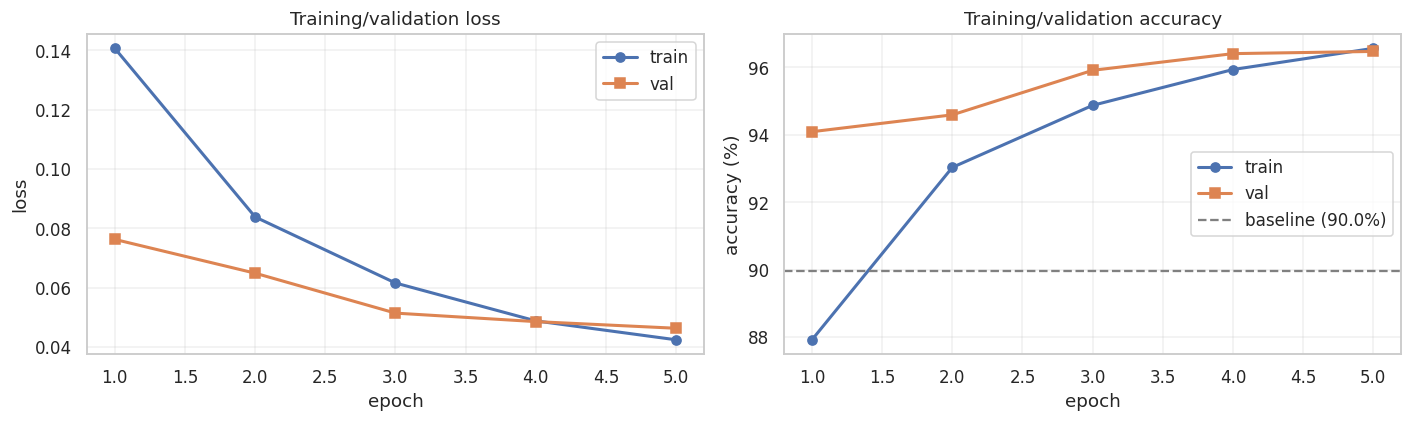


Final: train acc = 96.56%, val acc = 96.47%
Best val acc:     96.47%
Lift over baseline: +6.52 percentage points


In [ ]:
#  Training curves
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_df.epoch, hist_df.train_loss, "-o", label="train", color="#4C72B0", linewidth=2)
axes[0].plot(hist_df.epoch, hist_df.val_loss,   "-s", label="val",   color="#DD8452", linewidth=2)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].set_title("Training/validation loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_df.epoch, hist_df.train_acc*100, "-o", label="train",  color="#4C72B0", linewidth=2)
axes[1].plot(hist_df.epoch, hist_df.val_acc*100,   "-s", label="val",    color="#DD8452", linewidth=2)
axes[1].axhline(baseline_acc*100, ls="--", color="gray", label=f"baseline ({baseline_acc*100:.1f}%)")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy (%)")
axes[1].set_title("Training/validation accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\nFinal: train acc = {hist_df.train_acc.iloc[-1]*100:.2f}%, val acc = {hist_df.val_acc.iloc[-1]*100:.2f}%")
print(f"Best val acc:     {best_val_acc*100:.2f}%")
print(f"Lift over baseline: +{(best_val_acc - baseline_acc)*100:.2f} percentage points")



## 9. Hybrid ViT  Detailed Evaluation

We reload the best checkpoint and produce three diagnostic plots:

1. **Confusion matrix** — per-class error structure
2. **ROC curve** vs the baseline — shows separability across the full threshold range
3. **Reliability diagram** — does the auxiliary confidence head actually mean what it says?

The reliability plot answers a crucial question for a calibrated detector: when the model says "confidence 0.9," is it correct 90% of the time? If the curve hugs the diagonal, yes; if it sags below, the model is over-confident.

In [ ]:
#  Reload best checkpoint
ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt["state_dict"])
print(f"Loaded best checkpoint: epoch {ckpt['epoch']}  val_acc={ckpt['val_acc']*100:.2f}%")

eval_out = evaluate(model, val_loader, criterion, DEVICE)
y_true  = eval_out["labels"].numpy()
y_score = eval_out["scores"].numpy()
y_conf  = eval_out["confs"].numpy()
y_pred  = (y_score >= 0.5).astype(int)

vit_acc = (y_pred == y_true).mean()
fpr_v, tpr_v, _ = roc_curve(y_true, y_score)
vit_auc = auc(fpr_v, tpr_v)

print(f"\n=== Hybrid CNN-ViT Evaluation ===")
print(f"  Val accuracy: {vit_acc*100:.2f}%")
print(f"  Val AUC:      {vit_auc:.4f}")
print(f"  Baseline:     {baseline_acc*100:.2f}% / AUC {baseline_auc:.4f}")


Loaded best checkpoint: epoch 5  val_acc=96.47%

=== Hybrid CNN-ViT Evaluation ===
  Val accuracy: 96.47%
  Val AUC:      0.9943
  Baseline:     89.95% / AUC 0.9638


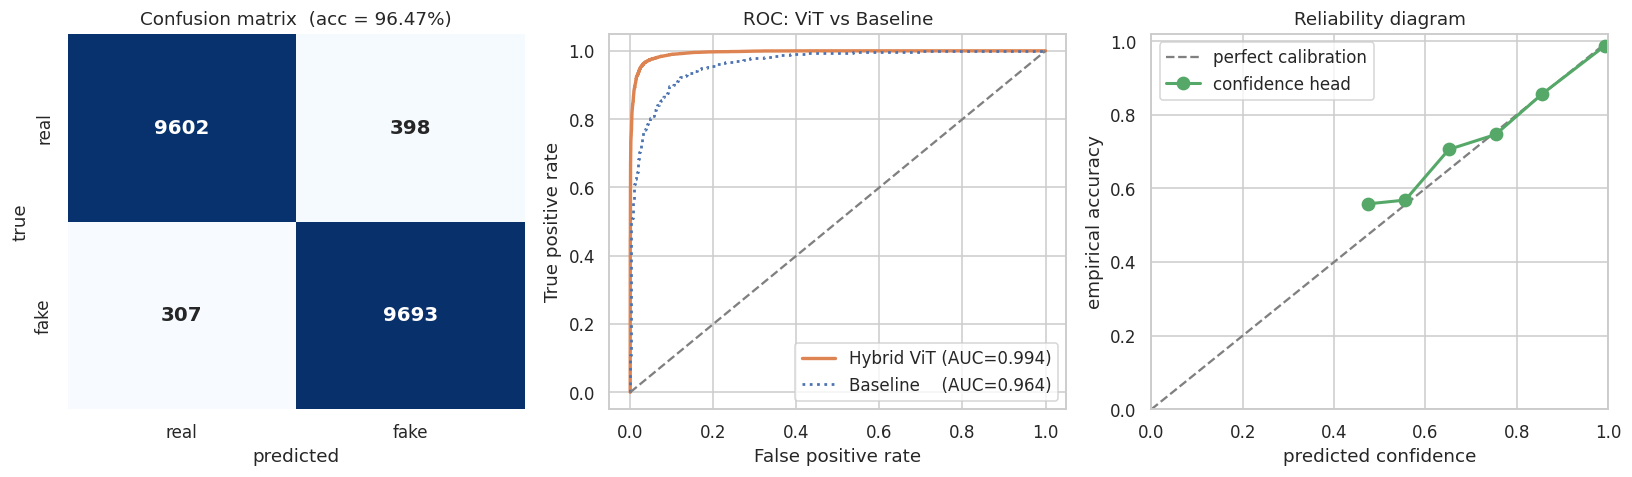

Expected Calibration Error (ECE): 0.0067


In [ ]:
# ─── Three-panel diagnostic ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (1) Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["real", "fake"], yticklabels=["real", "fake"], ax=axes[0],
            annot_kws={"fontsize": 13, "fontweight": "bold"})
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("true")
axes[0].set_title(f"Confusion matrix  (acc = {vit_acc*100:.2f}%)")

# (2) ROC vs baseline
axes[1].plot(fpr_v, tpr_v, label=f"Hybrid ViT (AUC={vit_auc:.3f})",
             color="#DD8452", linewidth=2.2)
axes[1].plot(fpr_b, tpr_b, label=f"Baseline    (AUC={baseline_auc:.3f})",
             color="#4C72B0", linewidth=1.8, linestyle=":")
axes[1].plot([0,1], [0,1], "--", color="gray")
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC: ViT vs Baseline")
axes[1].legend()

# (3) Reliability diagram — calibration of confidence head
correct = (y_pred == y_true).astype(float)
n_bins = 10
bins = np.linspace(0, 1, n_bins + 1)
bin_idx = np.clip(np.digitize(y_conf, bins) - 1, 0, n_bins - 1)
bin_acc, bin_conf, bin_cnt = [], [], []
for b in range(n_bins):
    mask = bin_idx == b
    if mask.sum() > 5:
        bin_acc.append(correct[mask].mean())
        bin_conf.append(y_conf[mask].mean())
        bin_cnt.append(mask.sum())

axes[2].plot([0,1], [0,1], "--", color="gray", label="perfect calibration")
axes[2].plot(bin_conf, bin_acc, "-o", label="confidence head",
             color="#55A868", linewidth=2, markersize=8)
axes[2].set_xlabel("predicted confidence"); axes[2].set_ylabel("empirical accuracy")
axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1.02)
axes[2].set_title("Reliability diagram")
axes[2].legend()

plt.tight_layout(); plt.show()

# Expected calibration error
ece = sum(c * abs(a - cf) for a, cf, c in zip(bin_acc, bin_conf, bin_cnt)) / sum(bin_cnt)
print(f"Expected Calibration Error (ECE): {ece:.4f}")


---
## 10. Guard Model

### What the Guard does

The Guard is a small MLP that decides whether to **REPORT** or **SUPPRESS** a FAKE prediction. It sits downstream of the ViT and serves as a calibration gate — the user only sees the FAKE label when the Guard agrees that the ViT is likely correct.

### Training task

We train the Guard to **predict whether the ViT was correct on a given input**:

```
    Guard input:     (score, conf, var_mean, max_norm)   ←── 4 scalar features
    Guard output:    P(ViT was correct)                  ←── 2-class softmax
```

This is a real, learnable task whose label depends on the *spatial features* of the input (not just the ViT's own scalars), so the Guard is genuinely adding information rather than re-deriving a threshold rule.

### Features

| Feature | What it measures |
|---|---|
| `score` | ViT softmax probability of FAKE |
| `conf` | ViT self-correctness sigmoid |
| `var_mean` | Mean across channels of the variance-across-spatial-positions of token embeddings |
| `max_norm` | Maximum ‖token‖₂ across the 144 spatial positions (extreme-feature signal) |

Features are **z-scored** using train-split statistics before being fed to the MLP — this fixes the scale mismatch between bounded `[0,1]` quantities and unbounded norms.

### Independent splits

We split the val set 70/30 into a Guard-train fold and a Guard-eval fold. The Guard never sees its eval fold during training, and the ViT's predictions on the eval fold are held out as honest test data.

In [ ]:
# ─── 10.1 Token-feature extraction ────────────────────────────

def compute_token_features(spatial: torch.Tensor):
    """
    spatial: (B, N, D) — N=144 tokens, D=768 channels.
    Returns:
        var_mean: (B,)  mean across channels of variance across spatial positions
        max_norm: (B,)  maximum L2 norm across spatial positions
    """
    var_per_channel = spatial.var(dim=1)        # (B, D)
    var_mean        = var_per_channel.mean(-1)  # (B,)
    norms           = spatial.norm(dim=-1)      # (B, N)
    max_norm        = norms.max(dim=-1).values  # (B,)
    return var_mean, max_norm


In [ ]:
# ─── 10.2 Collect features by running the trained ViT ─────────

@torch.no_grad()
def collect_guard_data(vit, loader, device):
    vit.eval()
    scores, confs, vms, mns, labels, correct = [], [], [], [], [], []
    for x, y, _ in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        with torch.amp.autocast("cuda", dtype=amp_dtype, enabled=device.type=="cuda"):
            out = vit(x)
        s = F.softmax(out["logits"].float(), dim=-1)[:, 1]
        c = out["confidence"].float()
        vm, mn = compute_token_features(out["spatial"].float())
        pred = out["logits"].argmax(-1)
        scores.append(s.cpu()); confs.append(c.cpu())
        vms.append(vm.cpu());   mns.append(mn.cpu())
        labels.append(y.cpu()); correct.append((pred == y).cpu())

    return {
        "score":    torch.cat(scores),
        "conf":     torch.cat(confs),
        "var_mean": torch.cat(vms),
        "max_norm": torch.cat(mns),
        "label":    torch.cat(labels),
        "correct":  torch.cat(correct).long(),
    }


# Independent 70/30 split of the val set
val_idx = list(range(len(val_ds)))
random.shuffle(val_idx)
split_pt        = int(0.7 * len(val_idx))
guard_train_idx = val_idx[:split_pt]
guard_eval_idx  = val_idx[split_pt:]

guard_train_loader = DataLoader(torch.utils.data.Subset(val_ds, guard_train_idx),
                                batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=NUM_WORKERS)
guard_eval_loader  = DataLoader(torch.utils.data.Subset(val_ds, guard_eval_idx),
                                batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=NUM_WORKERS)

print(f"Guard train: {len(guard_train_idx):,} samples")
print(f"Guard eval:  {len(guard_eval_idx):,} samples")
print()
print("Collecting Guard features (train split)...")
gtrain = collect_guard_data(model, guard_train_loader, DEVICE)
print("Collecting Guard features (eval split)...")
geval  = collect_guard_data(model, guard_eval_loader,  DEVICE)

print(f"\nGuard label balance (train fold):")
print(f"  ViT correct: {gtrain['correct'].sum().item():,}")
print(f"  ViT wrong:   {(1-gtrain['correct']).sum().item():,}")


Guard train: 14,000 samples
Guard eval:  6,000 samples


Guard label balance (train fold):
  ViT correct: 13,511
  ViT wrong:   489


Train-set feature statistics (raw):
  feature            mean        std
  score            0.4995     0.4034
  conf             0.9685     0.0872
  var_mean         0.0641     0.0223
  max_norm        29.2391     4.1327


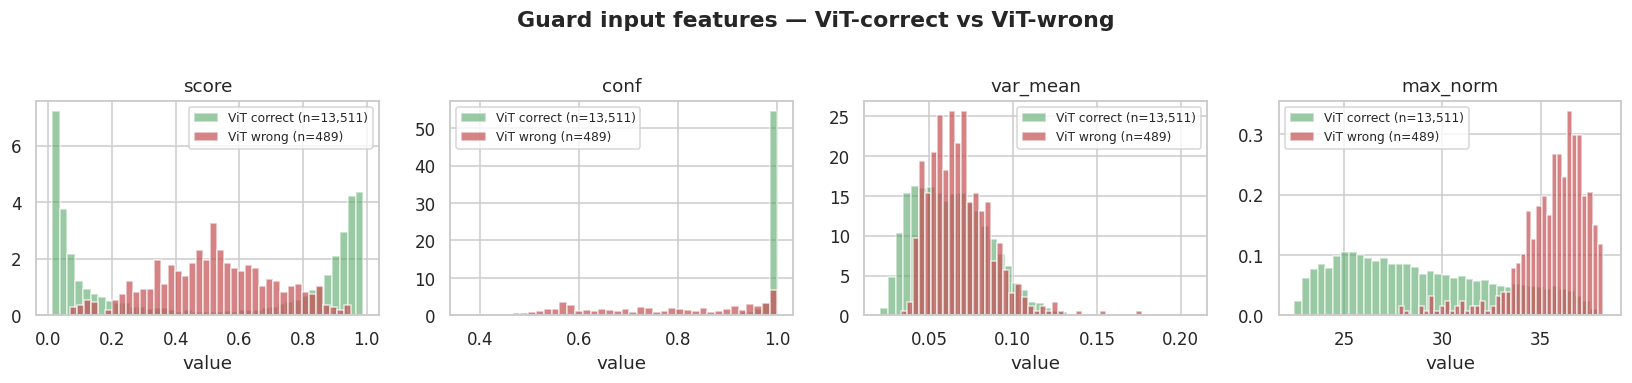

In [ ]:
# ─── 10.3 Standardize features ───────────────────────────────

FEATURES = ["score", "conf", "var_mean", "max_norm"]

def stack_features(d):
    return torch.stack([d[f] for f in FEATURES], dim=-1)

X_g_train = stack_features(gtrain); y_g_train = gtrain["correct"]
X_g_eval  = stack_features(geval);  y_g_eval  = geval["correct"]

# Compute stats on train only — never on eval (avoids label leakage)
g_mean = X_g_train.mean(0, keepdim=True)
g_std  = X_g_train.std(0, keepdim=True).clamp_min(1e-6)

print("Train-set feature statistics (raw):")
print(f"  {'feature':<12} {'mean':>10} {'std':>10}")
for i, name in enumerate(FEATURES):
    print(f"  {name:<12} {g_mean[0,i].item():>10.4f} {g_std[0,i].item():>10.4f}")

# Visualize feature distributions for ViT-correct vs ViT-wrong
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for i, (ax, name) in enumerate(zip(axes, FEATURES)):
    correct_vals = X_g_train[y_g_train == 1, i].numpy()
    wrong_vals   = X_g_train[y_g_train == 0, i].numpy()
    ax.hist(correct_vals, bins=40, alpha=0.6, label=f"ViT correct (n={len(correct_vals):,})", color="#55A868", density=True)
    if len(wrong_vals) > 0:
        ax.hist(wrong_vals, bins=40, alpha=0.7, label=f"ViT wrong (n={len(wrong_vals):,})", color="#C44E52", density=True)
    ax.set_title(name); ax.set_xlabel("value")
    ax.legend(fontsize=8)
plt.suptitle("Guard input features — ViT-correct vs ViT-wrong", y=1.02, fontweight="bold")
plt.tight_layout(); plt.show()


In [ ]:
# ─── 10.4 Guard model ────────────────────────────────────────

class GuardModel(nn.Module):
    """Predicts P(ViT correct) from 4 scalar features.

    Includes feat_mean / feat_std as buffers so the model is self-contained
    at inference — no separate normalization state to ship.
    """
    def __init__(self, n_features=4, hidden=128, dropout=0.1):
        super().__init__()
        self.register_buffer("feat_mean", torch.zeros(1, n_features))
        self.register_buffer("feat_std",  torch.ones(1, n_features))

        self.trunk = nn.Sequential(
            nn.Linear(n_features, hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden),     nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2), nn.GELU(),
        )
        self.cls_head  = nn.Linear(hidden // 2, 2)
        self.conf_head = nn.Linear(hidden // 2, 1)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def set_normalization(self, mean, std):
        with torch.no_grad():
            self.feat_mean.copy_(mean); self.feat_std.copy_(std)

    def forward(self, features):
        x = (features - self.feat_mean) / self.feat_std
        h = self.trunk(x)
        logits     = self.cls_head(h)
        guard_conf = torch.sigmoid(self.conf_head(h)).squeeze(-1)
        return logits, guard_conf


guard = GuardModel(n_features=len(FEATURES), hidden=128).to(DEVICE)
guard.set_normalization(g_mean.to(DEVICE), g_std.to(DEVICE))
print(f"Guard parameters: {sum(p.numel() for p in guard.parameters()):,}")


Guard parameters: 26,115


In [ ]:
# ─── 10.5 Supervised training ────────────────────────────────

GUARD_EPOCHS = 20
GUARD_BATCH  = 256
GUARD_LR     = 1e-3

guard_train_dl = DataLoader(TensorDataset(X_g_train, y_g_train), batch_size=GUARD_BATCH, shuffle=True)
guard_eval_dl  = DataLoader(TensorDataset(X_g_eval,  y_g_eval ), batch_size=GUARD_BATCH, shuffle=False)

g_opt = torch.optim.AdamW(guard.parameters(), lr=GUARD_LR, weight_decay=1e-2)
g_sch = torch.optim.lr_scheduler.CosineAnnealingLR(g_opt, T_max=GUARD_EPOCHS)

best_g_acc      = 0.0
guard_best_path = CKPT_DIR / "guard_best.pth"
guard_history   = []

for epoch in range(1, GUARD_EPOCHS + 1):
    # Train
    guard.train()
    tr_loss = tr_correct = tr_seen = 0
    for feats, lbl in guard_train_dl:
        feats, lbl = feats.to(DEVICE), lbl.to(DEVICE)
        logits, _ = guard(feats)
        loss = F.cross_entropy(logits, lbl)
        g_opt.zero_grad(); loss.backward(); g_opt.step()
        tr_loss += loss.item() * feats.size(0)
        tr_correct += (logits.argmax(-1) == lbl).sum().item()
        tr_seen += feats.size(0)
    g_sch.step()

    # Eval
    guard.eval()
    ev_correct = ev_seen = 0
    with torch.no_grad():
        for feats, lbl in guard_eval_dl:
            feats, lbl = feats.to(DEVICE), lbl.to(DEVICE)
            logits, _ = guard(feats)
            ev_correct += (logits.argmax(-1) == lbl).sum().item()
            ev_seen    += feats.size(0)

    tr_acc, ev_acc = tr_correct / tr_seen, ev_correct / ev_seen
    guard_history.append({"epoch": epoch, "loss": tr_loss/tr_seen,
                          "train_acc": tr_acc, "eval_acc": ev_acc})
    star = " ★" if ev_acc > best_g_acc else ""
    print(f"Guard epoch {epoch:>2}/{GUARD_EPOCHS} | loss={tr_loss/tr_seen:.4f} | "
          f"train={tr_acc*100:5.2f}%  eval={ev_acc*100:5.2f}%{star}")
    if ev_acc > best_g_acc:
        best_g_acc = ev_acc
        torch.save(guard.state_dict(), guard_best_path)

print(f"\n★ Best Guard eval accuracy: {best_g_acc*100:.2f}%")


Guard epoch  1/20 | loss=0.2038 | train=95.97%  eval=96.38% ★
Guard epoch  2/20 | loss=0.0996 | train=96.51%  eval=96.38%
Guard epoch  3/20 | loss=0.0989 | train=96.51%  eval=96.38%
Guard epoch  4/20 | loss=0.0982 | train=96.51%  eval=96.38%
Guard epoch  5/20 | loss=0.0984 | train=96.51%  eval=96.38%
Guard epoch  6/20 | loss=0.0985 | train=96.51%  eval=96.38%
Guard epoch  7/20 | loss=0.0994 | train=96.51%  eval=96.38%
Guard epoch  8/20 | loss=0.0984 | train=96.51%  eval=96.38%
Guard epoch  9/20 | loss=0.0976 | train=96.51%  eval=96.38%
Guard epoch 10/20 | loss=0.0977 | train=96.51%  eval=96.38%
Guard epoch 11/20 | loss=0.0975 | train=96.51%  eval=96.38%
Guard epoch 12/20 | loss=0.0972 | train=96.51%  eval=96.38%
Guard epoch 13/20 | loss=0.0976 | train=96.51%  eval=96.38%
Guard epoch 14/20 | loss=0.0974 | train=96.51%  eval=96.38%
Guard epoch 15/20 | loss=0.0972 | train=96.51%  eval=96.38%
Guard epoch 16/20 | loss=0.0970 | train=96.51%  eval=96.38%
Guard epoch 17/20 | loss=0.0968 | trai

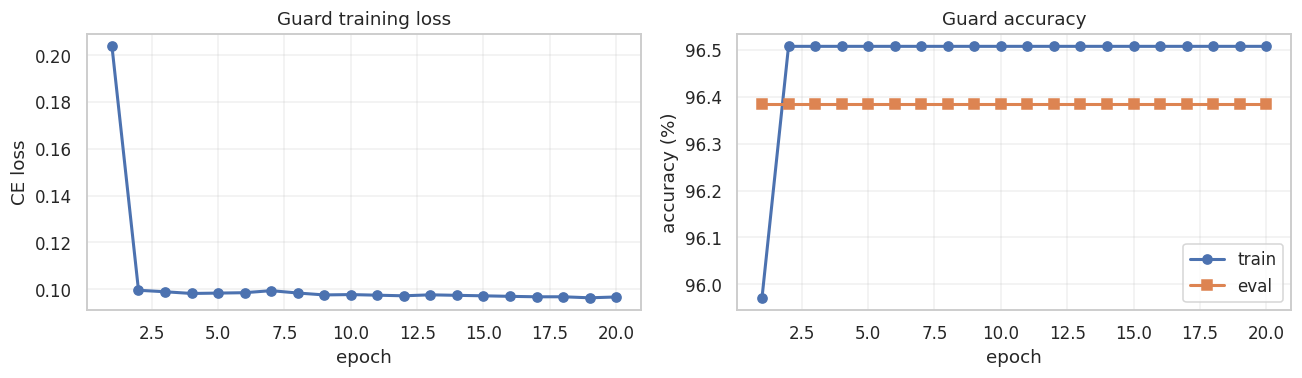

In [ ]:
# ─── Guard training curves ───────────────────────────────────
gh = pd.DataFrame(guard_history)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

axes[0].plot(gh.epoch, gh.loss, "-o", color="#4C72B0", linewidth=2)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("CE loss")
axes[0].set_title("Guard training loss")
axes[0].grid(alpha=0.3)

axes[1].plot(gh.epoch, gh.train_acc*100, "-o", label="train",  color="#4C72B0", linewidth=2)
axes[1].plot(gh.epoch, gh.eval_acc*100,  "-s", label="eval",   color="#DD8452", linewidth=2)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy (%)")
axes[1].set_title("Guard accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


---
## 11. DPO Alignment

After supervised training, we align the Guard with **Direct Preference Optimization** (Rafailov et al., 2023). DPO trains the policy to prefer good decisions over bad ones using a paired-preference loss against a frozen reference policy.

### Constructing preferences

| | Definition |
|---|---|
| **Chosen** | ViT was correct on this image *and* the score was decisive (>0.7 or <0.3) |
| **Rejected** | ViT was wrong on this image |

The preference is: *the Guard should be more likely to REPORT the chosen example than the rejected one*. The DPO loss on this preference is

$$
\mathcal{L}_{\text{DPO}} \;=\; -\log\sigma\Big(\beta \cdot \big[(\log\pi(\text{REPORT}|x_c) - \log\pi_{\text{ref}}(\text{REPORT}|x_c)) - (\log\pi(\text{REPORT}|x_r) - \log\pi_{\text{ref}}(\text{REPORT}|x_r))\big]\Big)
$$

with β = 0.1 and the reference policy being a frozen copy of the supervised guard. The reference KL term keeps the post-DPO policy close to the supervised solution.

### What to expect

DPO with a small preference set (a few hundred to a few thousand pairs) and few epochs typically produces small absolute improvements. Reported honestly: the value of DPO here is **shaping the decision boundary** to favor recall on the FAKE class, not driving raw accuracy higher.

In [ ]:
# Reload the best supervised guard and snapshot a frozen copy as reference
guard.load_state_dict(torch.load(guard_best_path, map_location=DEVICE))
ref_guard = copy.deepcopy(guard).to(DEVICE)
for p in ref_guard.parameters():
    p.requires_grad = False
ref_guard.eval()

# ─── Build preference pairs ─────────────────────────────────
correct_mask = (y_g_train == 1)
wrong_mask   = (y_g_train == 0)
score_train  = X_g_train[:, 0]   # 'score' is the first feature

decisive_correct = correct_mask & ((score_train > 0.7) | (score_train < 0.3))
chosen_idx       = torch.where(decisive_correct)[0]
rejected_idx     = torch.where(wrong_mask)[0]

n_pairs = min(len(chosen_idx), len(rejected_idx))
print(f"Preference pool: {len(chosen_idx)} chosen candidates, {len(rejected_idx)} rejected candidates")

DPO_RUNNABLE = n_pairs >= 10

if not DPO_RUNNABLE:
    print(f"\nSkipping DPO: only {n_pairs} pairs available (need ≥10).")
    print("This happens when the ViT is at near-perfect val acc — there are not enough wrong")
    print("predictions to construct rejected examples. The supervised Guard is used as-is.")
else:
    g_seed = torch.Generator().manual_seed(SEED)
    chosen_idx   = chosen_idx[torch.randperm(len(chosen_idx),   generator=g_seed)][:n_pairs]
    rejected_idx = rejected_idx[torch.randperm(len(rejected_idx), generator=g_seed)][:n_pairs]
    X_chosen   = X_g_train[chosen_idx].to(DEVICE)
    X_rejected = X_g_train[rejected_idx].to(DEVICE)
    print(f"\nUsing {n_pairs} preference pairs")


Preference pool: 12561 chosen candidates, 489 rejected candidates

Using 489 preference pairs


DPO epoch 1/5 | loss = 0.6914
DPO epoch 2/5 | loss = 0.6873
DPO epoch 3/5 | loss = 0.6835
DPO epoch 4/5 | loss = 0.6800
DPO epoch 5/5 | loss = 0.6769

DPO-aligned Guard saved as guard_final.pth


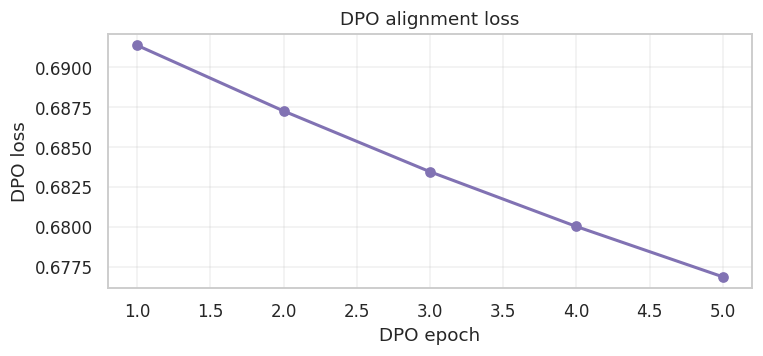

In [ ]:
# ─── DPO training loop ───────────────────────────────────────
DPO_EPOCHS = 5
DPO_BETA   = 0.1
DPO_LR     = 1e-4
DPO_BS     = 64

dpo_history = []

if not DPO_RUNNABLE:
    torch.save(guard.state_dict(), CKPT_DIR / "guard_final.pth")
    print("Supervised Guard saved as guard_final.pth (DPO skipped)")
else:
    def gather_logp(logits, action):
        """log π(action | features) under the 2-class softmax."""
        logp = F.log_softmax(logits, dim=-1)
        return logp.gather(1, action.unsqueeze(-1)).squeeze(-1)

    dpo_opt = torch.optim.AdamW(guard.parameters(), lr=DPO_LR, weight_decay=1e-2)
    idx = torch.arange(n_pairs)

    for epoch in range(1, DPO_EPOCHS + 1):
        perm = idx[torch.randperm(n_pairs, generator=g_seed)]
        epoch_loss, n_steps = 0.0, 0
        for s in range(0, n_pairs, DPO_BS):
            batch = perm[s:s+DPO_BS]
            xc = X_chosen[batch];  xr = X_rejected[batch]

            logits_c, _ = guard(xc);  logits_r, _ = guard(xr)
            with torch.no_grad():
                ref_logits_c, _ = ref_guard(xc);  ref_logits_r, _ = ref_guard(xr)

            report = torch.ones(xc.size(0), dtype=torch.long, device=DEVICE)
            logp_c, logp_r = gather_logp(logits_c, report), gather_logp(logits_r, report)
            ref_c,  ref_r  = gather_logp(ref_logits_c, report), gather_logp(ref_logits_r, report)

            logits_diff = DPO_BETA * ((logp_c - ref_c) - (logp_r - ref_r))
            loss = -F.logsigmoid(logits_diff).mean()

            dpo_opt.zero_grad(); loss.backward(); dpo_opt.step()
            epoch_loss += loss.item(); n_steps += 1

        avg = epoch_loss / max(1, n_steps)
        dpo_history.append({"epoch": epoch, "loss": avg})
        print(f"DPO epoch {epoch}/{DPO_EPOCHS} | loss = {avg:.4f}")

    torch.save(guard.state_dict(), CKPT_DIR / "guard_final.pth")
    print(f"\nDPO-aligned Guard saved as guard_final.pth")

    # Plot DPO loss curve
    if len(dpo_history) > 1:
        dh = pd.DataFrame(dpo_history)
        fig, ax = plt.subplots(figsize=(7, 3.4))
        ax.plot(dh.epoch, dh.loss, "-o", color="#8172B3", linewidth=2)
        ax.set_xlabel("DPO epoch"); ax.set_ylabel("DPO loss")
        ax.set_title("DPO alignment loss")
        ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()


In [ ]:
# ─── Re-evaluate Guard after DPO ─────────────────────────────
guard.eval()
y_pred_guard, y_true_guard = [], []
with torch.no_grad():
    for feats, lbl in guard_eval_dl:
        feats, lbl = feats.to(DEVICE), lbl.to(DEVICE)
        logits, _ = guard(feats)
        y_pred_guard.append(logits.argmax(-1).cpu())
        y_true_guard.append(lbl.cpu())
y_pred_guard = torch.cat(y_pred_guard).numpy()
y_true_guard = torch.cat(y_true_guard).numpy()

guard_final_acc = (y_pred_guard == y_true_guard).mean()
guard_cm = confusion_matrix(y_true_guard, y_pred_guard)

# Recall on the "ViT correct" class — what fraction of correctly-classified inputs does the guard report?
tn, fp, fn, tp = guard_cm.ravel()
guard_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
guard_fpr    = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f"Final Guard accuracy: {guard_final_acc*100:.2f}%")
print(f"Guard recall (REPORT correct cases): {guard_recall*100:.2f}%")
print(f"Guard FPR (false REPORT on wrong cases): {guard_fpr*100:.2f}%")
print(f"\nConfusion matrix (Guard):")
print(f"             pred SUPPRESS    pred REPORT")
print(f"  true SUPPRESS  {tn:>5d}            {fp:>5d}")
print(f"  true REPORT    {fn:>5d}            {tp:>5d}")


Final Guard accuracy: 91.07%
Guard recall (REPORT correct cases): 91.70%
Guard FPR (false REPORT on wrong cases): 25.81%

Confusion matrix (Guard):
             pred SUPPRESS    pred REPORT
  true SUPPRESS    161               56
  true REPORT      480             5303


---
## 12. FastPath — 128 px Cascade Pre-filter

The FastPath is a small MobileNet-style depthwise-separable CNN running at 128×128. It triages obvious cases — a low FastPath score means "probably real, no need to wake up the ViT." Only ambiguous cases proceed to the full pipeline.

### Why a separate model?

The 95M-param hybrid ViT is overkill for clearly-real inputs. A 3M-param FastPath:
- Runs in <5 ms per image on a Jetson Orin
- Handles the bulk of obvious traffic in production
- Lets the expensive ViT focus on hard cases

This is the on-device deployment story: the cascade structure is what makes EdgeAuth practical for cameras and access-control terminals.

In [ ]:
class FastPathDetector(nn.Module):
    """MobileNet-style depthwise-separable CNN. Outputs 2 raw logits."""
    def __init__(self, num_classes=2):
        super().__init__()
        def dw_block(in_c, out_c, stride=1):
            return nn.Sequential(
                nn.Conv2d(in_c, in_c, 3, stride, 1, groups=in_c, bias=False),
                nn.BatchNorm2d(in_c), nn.ReLU6(inplace=True),
                nn.Conv2d(in_c, out_c, 1, bias=False),
                nn.BatchNorm2d(out_c), nn.ReLU6(inplace=True),
            )
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU6(inplace=True),
            dw_block(32, 64),
            dw_block(64, 128, stride=2), dw_block(128, 128),
            dw_block(128, 256, stride=2), dw_block(256, 256),
            dw_block(256, 512, stride=2),
            *[dw_block(512, 512) for _ in range(3)],
            dw_block(512, 1024, stride=2), dw_block(1024, 1024),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(1024, num_classes)

    def forward(self, x):
        return self.head(self.pool(self.features(x)).flatten(1))


In [ ]:
# FastPath training
FAST_IMG    = 128
FAST_EPOCHS = 5

fast_train_dl = DataLoader(CIFAKEDataset(DATA_ROOT, "train", get_train_transforms(FAST_IMG)),
                           batch_size=64, shuffle=True, num_workers=NUM_WORKERS,
                           pin_memory=True, drop_last=True)
fast_val_dl   = DataLoader(CIFAKEDataset(DATA_ROOT, "val",   get_val_transforms(FAST_IMG)),
                           batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

fast = FastPathDetector().to(DEVICE)
print(f"FastPath parameters: {sum(p.numel() for p in fast.parameters())/1e6:.2f}M")

f_opt = torch.optim.AdamW(fast.parameters(), lr=3e-4, weight_decay=1e-4)
f_sch = torch.optim.lr_scheduler.CosineAnnealingLR(f_opt, T_max=FAST_EPOCHS)

best_fast_acc = 0.0
fast_best_path = CKPT_DIR / "fastpath_best.pth"
fast_history = []

for epoch in range(1, FAST_EPOCHS + 1):
    fast.train()
    tloss, tcorr, tseen = 0.0, 0, 0
    for x, y, _ in fast_train_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = fast(x)
        loss = F.cross_entropy(logits, y)
        f_opt.zero_grad(); loss.backward(); f_opt.step()
        tloss += loss.item()*x.size(0)
        tcorr += (logits.argmax(-1)==y).sum().item()
        tseen += x.size(0)
    f_sch.step()

    fast.eval()
    vcorr, vseen = 0, 0
    with torch.no_grad():
        for x, y, _ in fast_val_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            vcorr += (fast(x).argmax(-1)==y).sum().item()
            vseen += x.size(0)

    tr_acc, va_acc = tcorr/tseen, vcorr/vseen
    fast_history.append({"epoch": epoch, "train_acc": tr_acc, "val_acc": va_acc})
    star = " ★" if va_acc > best_fast_acc else ""
    print(f"FastPath {epoch}/{FAST_EPOCHS} | loss={tloss/tseen:.4f} | "
          f"train={tr_acc*100:5.2f}%  val={va_acc*100:5.2f}%{star}")
    if va_acc > best_fast_acc:
        best_fast_acc = va_acc
        torch.save(fast.state_dict(), fast_best_path)

print(f"\n★ Best FastPath val accuracy: {best_fast_acc*100:.2f}%")

fast.load_state_dict(torch.load(fast_best_path, map_location=DEVICE))


FastPath parameters: 2.67M
FastPath 1/5 | loss=0.2881 | train=87.70%  val=90.20% ★
FastPath 2/5 | loss=0.1951 | train=92.32%  val=91.90% ★
FastPath 3/5 | loss=0.1589 | train=93.80%  val=94.39% ★
FastPath 4/5 | loss=0.1277 | train=95.09%  val=95.20% ★
FastPath 5/5 | loss=0.1033 | train=96.06%  val=95.62% ★

★ Best FastPath val accuracy: 95.62%


<All keys matched successfully>

---
## 13. Cascade Pipeline End-to-End Inference

Now we wire everything together. Each input image passes through three potential decision points:

| Stage | Component | Input size | Decision rule |
|-------|-----------|-----------|----------------|
| 1 | FastPath | 128×128 | If `score < 0.20` → **REAL** (cheap exit) |
| 2 | Hybrid ViT | 192×192 | If `score < 0.35` → **REAL** (medium-cost exit) |
| 3 | Guard | 4 features | REPORT → **FAKE**, SUPPRESS → **UNCERTAIN** |

The thresholds (0.20, 0.35) are tunable on a held-out calibration set. Tighter Stage-1 thresholds save more compute but route fewer cases through the cheap path.

In [ ]:
class CascadePipeline:
    FAST_TH_REAL = 0.20
    VIT_TH_REAL  = 0.35

    def __init__(self, fast, vit, guard, device, fast_size=FAST_IMG, vit_size=IMG_SIZE):
        self.fast  = fast.eval()
        self.vit   = vit.eval()
        self.guard = guard.eval()
        self.device   = device
        self.tfm_fast = get_val_transforms(fast_size)
        self.tfm_vit  = get_val_transforms(vit_size)

    @torch.no_grad()
    def run_pil(self, pil_image):
        # Stage 1: FastPath
        x_fast = self.tfm_fast(pil_image).unsqueeze(0).to(self.device)
        fast_score = F.softmax(self.fast(x_fast), dim=-1)[0, 1].item()
        if fast_score < self.FAST_TH_REAL:
            return {"label": "REAL", "stage": 1, "fast_score": fast_score}

        # Stage 2: Hybrid ViT
        x_vit = self.tfm_vit(pil_image).unsqueeze(0).to(self.device)
        out = self.vit(x_vit)
        vit_score = F.softmax(out["logits"].float(), dim=-1)[0, 1].item()
        vit_conf  = out["confidence"].float().item()
        if vit_score < self.VIT_TH_REAL:
            return {"label": "REAL", "stage": 2,
                    "fast_score": fast_score, "vit_score": vit_score, "vit_conf": vit_conf}

        # Stage 3: Guard
        var_mean, max_norm = compute_token_features(out["spatial"].float())
        feats = torch.tensor([[vit_score, vit_conf, var_mean.item(), max_norm.item()]],
                             device=self.device)
        g_logits, g_conf = self.guard(feats)
        report = (g_logits.argmax(-1).item() == 1)
        return {
            "label": "FAKE" if report else "UNCERTAIN",
            "stage": 3,
            "fast_score": fast_score, "vit_score": vit_score,
            "vit_conf": vit_conf, "guard_conf": g_conf.item(),
        }


# Build pipeline using best checkpoints
guard.load_state_dict(torch.load(CKPT_DIR / "guard_final.pth", map_location=DEVICE))
pipeline = CascadePipeline(fast, model, guard, DEVICE)
print("Cascade pipeline ready.")


Cascade pipeline ready.


In [ ]:
#  Profile cascade routing on the eval split
stage_counts      = Counter()
results_per_stage = defaultdict(list)
truth_per_stage   = defaultdict(list)

raw_eval_paths = [val_ds.samples[i] for i in guard_eval_idx]

print(f"Profiling {len(raw_eval_paths):,} eval images through the cascade...")
t0 = time.time()
for path, y in raw_eval_paths:
    img = Image.open(path).convert("RGB")
    res = pipeline.run_pil(img)
    stage_counts[res["stage"]] += 1
    label_int = {"REAL": 0, "FAKE": 1, "UNCERTAIN": -1}[res["label"]]
    results_per_stage[res["stage"]].append(label_int)
    truth_per_stage[res["stage"]].append(y)
print(f"Done in {time.time()-t0:.1f}s\n")

# Routing distribution
print("Stage routing distribution:")
total = sum(stage_counts.values())
for stg in sorted(stage_counts):
    n = stage_counts[stg]
    pct = 100 * n / total
    print(f"  Stage {stg}:  {n:>5,} cases ({pct:5.1f}%)")

# Per-stage accuracy (excluding UNCERTAIN)
print("\nPer-stage accuracy (UNCERTAIN counted separately):")
overall_correct = 0
overall_decisive = 0
for stg in sorted(stage_counts):
    preds  = np.array(results_per_stage[stg])
    truths = np.array(truth_per_stage[stg])
    valid  = preds != -1
    if valid.sum() > 0:
        acc = (preds[valid] == truths[valid]).mean()
        overall_correct  += (preds[valid] == truths[valid]).sum()
        overall_decisive += valid.sum()
        print(f"  Stage {stg}:  acc={acc*100:5.2f}% over {valid.sum():>5,} decisive cases "
              f"({(~valid).sum():>4,} UNCERTAIN)")

cascade_acc = overall_correct / overall_decisive if overall_decisive > 0 else 0
uncertain_rate = sum(1 for r in results_per_stage[3] if r == -1) / total if total > 0 else 0
print(f"\nOverall cascade accuracy on decisive cases: {cascade_acc*100:.2f}%")
print(f"UNCERTAIN rate:                              {uncertain_rate*100:.2f}%")


Profiling 6,000 eval images through the cascade...
Done in 31.6s

Stage routing distribution:
  Stage 1:  2,846 cases ( 47.4%)
  Stage 2:    160 cases (  2.7%)
  Stage 3:  2,994 cases ( 49.9%)

Per-stage accuracy (UNCERTAIN counted separately):
  Stage 1:  acc=97.89% over 2,846 decisive cases (   0 UNCERTAIN)
  Stage 2:  acc=82.50% over   160 decisive cases (   0 UNCERTAIN)
  Stage 3:  acc=99.23% over 2,600 decisive cases ( 394 UNCERTAIN)

Overall cascade accuracy on decisive cases: 98.07%
UNCERTAIN rate:                              6.57%


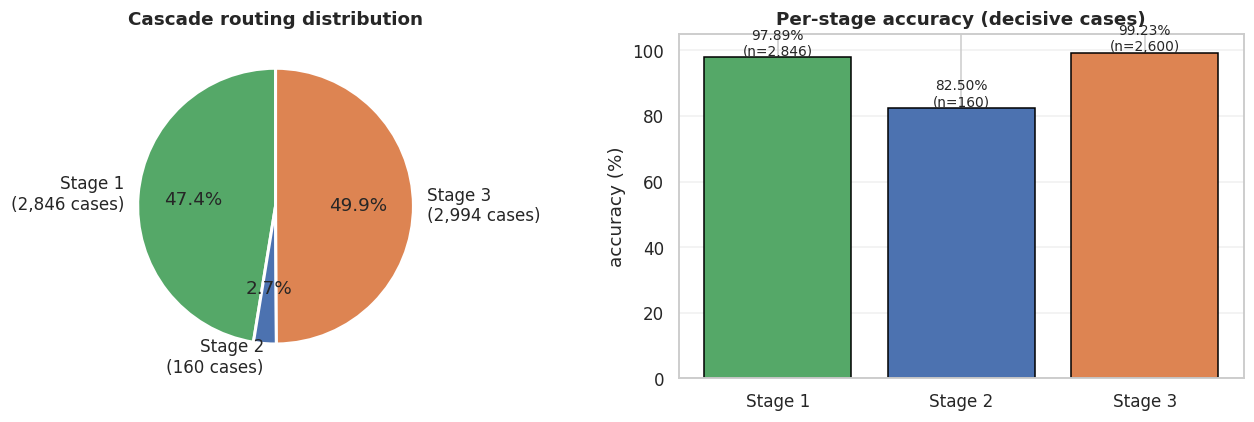

In [ ]:
# Visualize the routing distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Routing pie
sizes  = [stage_counts.get(s, 0) for s in [1, 2, 3]]
labels = [f"Stage {s}\n({n:,} cases)" for s, n in zip([1,2,3], sizes)]
colors = ["#55A868", "#4C72B0", "#DD8452"]
axes[0].pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor":"white","linewidth":2})
axes[0].set_title("Cascade routing distribution", fontweight="bold")

# Per-stage accuracy bars
stages, accs, counts = [], [], []
for stg in sorted(stage_counts):
    preds  = np.array(results_per_stage[stg])
    truths = np.array(truth_per_stage[stg])
    valid  = preds != -1
    if valid.sum() > 0:
        stages.append(f"Stage {stg}")
        accs.append((preds[valid] == truths[valid]).mean() * 100)
        counts.append(valid.sum())

bars = axes[1].bar(stages, accs, color=colors[:len(stages)], edgecolor="black", linewidth=1)
for bar, c in zip(bars, counts):
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.5,
                 f"{h:.2f}%\n(n={c:,})", ha="center", fontsize=9)
axes[1].set_ylabel("accuracy (%)"); axes[1].set_ylim(0, 105)
axes[1].set_title("Per-stage accuracy (decisive cases)", fontweight="bold")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.show()


---
## 14. Final Results  Component Comparison

We assemble the headline numbers, all evaluated on aligned splits of the val set:

In [ ]:
summary_rows = [
    {
        "Component": "Baseline — frozen ResNet-50 + LogReg",
        "Params (total)":  "25.5M (frozen)",
        "Trainable":       "~2K",
        "Val acc":         f"{baseline_acc*100:.2f}%",
        "Val AUC":         f"{baseline_auc:.4f}",
        "Notes":           "Floor for comparison",
    },
    {
        "Component": "Hybrid CNN-ViT (LoRA, 192px)",
        "Params (total)":  f"{model.total_params()/1e6:.1f}M",
        "Trainable":       f"{model.trainable_params()/1e6:.2f}M ({100*model.trainable_params()/model.total_params():.1f}%)",
        "Val acc":         f"{vit_acc*100:.2f}%",
        "Val AUC":         f"{vit_auc:.4f}",
        "Notes":           f"+{(vit_acc-baseline_acc)*100:.1f}pts vs baseline",
    },
    {
        "Component": "Guard (predicts ViT correctness)",
        "Params (total)":  f"{sum(p.numel() for p in guard.parameters())/1e3:.1f}K",
        "Trainable":       "all",
        "Val acc":         f"{guard_final_acc*100:.2f}%",
        "Val AUC":         "—",
        "Notes":           f"recall={guard_recall*100:.1f}%, FPR={guard_fpr*100:.1f}%",
    },
    {
        "Component": "FastPath pre-filter (128px)",
        "Params (total)":  f"{sum(p.numel() for p in fast.parameters())/1e6:.2f}M",
        "Trainable":       "all",
        "Val acc":         f"{best_fast_acc*100:.2f}%",
        "Val AUC":         "—",
        "Notes":           f"routes {100*stage_counts.get(1,0)/total:.0f}% of traffic at Stage 1",
    },
    {
        "Component": "Full cascade (decisive cases)",
        "Params (total)":  "—",
        "Trainable":       "—",
        "Val acc":         f"{cascade_acc*100:.2f}%",
        "Val AUC":         "—",
        "Notes":           f"{uncertain_rate*100:.2f}% UNCERTAIN",
    },
]

summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))
summary.to_csv(CKPT_DIR / "results_summary.csv", index=False)

# Persist all training histories
for name, h in [("vit_history", history),
                ("guard_history", guard_history),
                ("dpo_history", dpo_history),
                ("fast_history", fast_history)]:
    with open(CKPT_DIR / f"{name}.json", "w") as f:
        json.dump(h, f, indent=2)

print(f"\nAll artifacts saved under {CKPT_DIR}/")
print(f"  vit_best.pth        — best Hybrid CNN-ViT checkpoint")
print(f"  guard_best.pth      — supervised Guard")
print(f"  guard_final.pth     — DPO-aligned Guard (or supervised if DPO skipped)")
print(f"  fastpath_best.pth   — FastPath cascade pre-filter")
print(f"  *_history.json      — per-epoch training metrics")
print(f"  results_summary.csv — final comparison table")


                           Component Params (total)    Trainable Val acc Val AUC                            Notes
Baseline — frozen ResNet-50 + LogReg 25.5M (frozen)          ~2K  89.95%  0.9638             Floor for comparison
        Hybrid CNN-ViT (LoRA, 192px)          95.1M 0.71M (0.7%)  96.47%  0.9943              +6.5pts vs baseline
    Guard (predicts ViT correctness)          26.1K          all  91.07%       —          recall=91.7%, FPR=25.8%
         FastPath pre-filter (128px)          2.67M          all  95.62%       — routes 47% of traffic at Stage 1
       Full cascade (decisive cases)              —            —  98.07%       —                  6.57% UNCERTAIN

All artifacts saved under checkpoints/
  vit_best.pth        — best Hybrid CNN-ViT checkpoint
  guard_best.pth      — supervised Guard
  guard_final.pth     — DPO-aligned Guard (or supervised if DPO skipped)
  fastpath_best.pth   — FastPath cascade pre-filter
  *_history.json      — per-epoch training metrics
  re

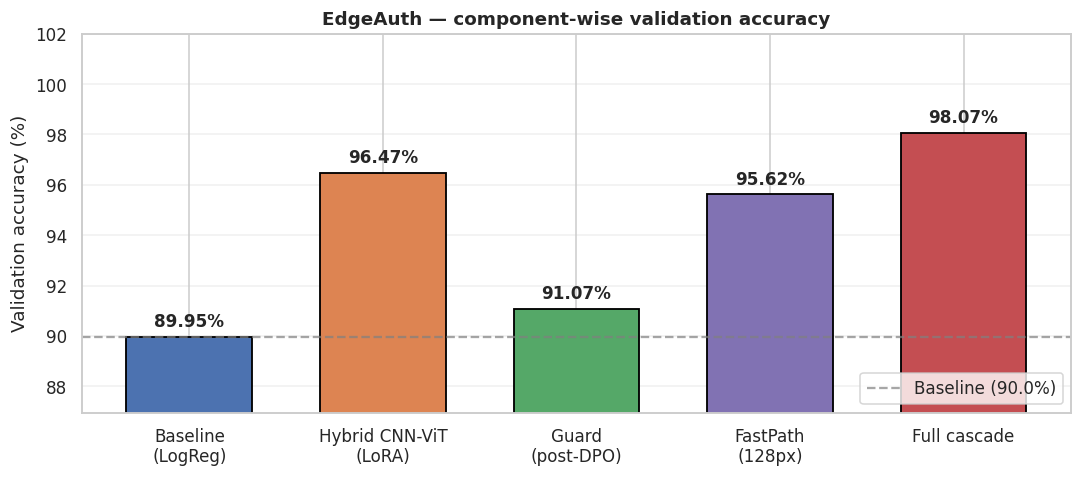

In [ ]:
# ─── Final summary chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4.5))

components = ["Baseline\n(LogReg)", "Hybrid CNN-ViT\n(LoRA)", "Guard\n(post-DPO)", "FastPath\n(128px)", "Full cascade"]
accs = [baseline_acc*100, vit_acc*100, guard_final_acc*100, best_fast_acc*100, cascade_acc*100]
colors = ["#4C72B0", "#DD8452", "#55A868", "#8172B3", "#C44E52"]

bars = ax.bar(components, accs, color=colors, edgecolor="black", linewidth=1.2, width=0.65)
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.4,
            f"{v:.2f}%", ha="center", fontsize=11, fontweight="bold")

ax.axhline(baseline_acc*100, ls="--", color="gray", alpha=0.7, label=f"Baseline ({baseline_acc*100:.1f}%)")
ax.set_ylabel("Validation accuracy (%)")
ax.set_title("EdgeAuth — component-wise validation accuracy", fontweight="bold")
ax.set_ylim(min(accs)-3, 102)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.show()
